# What does a typical Kalpa order look like, stated so that one large order cannot move it?

**Week 1, Monday, chapter 4 of 6.** Marketing's case for Rs 12 crore values every new customer
by the order they will place. Meera wants to know what that order is worth, and Anand has said
how he will read the answer:

> Meera: "What does a typical order look like?"
> Anand: "No averages. One business customer can move an average."

**Who needs the answer.** Meera and the marketing lead need a typical order to price what a new
customer brings in the acquisition payback, and Anand will reject any answer that one order can
move. A first order valued several times too high makes Rs 12 crore look cheap and the payback
look short.

**The questions on the way.**

1. Which middle survives one large order?
2. What is the median Kalpa order?
3. Where does a trimmed mean of Kalpa's 30 orders land?
4. What goes wrong when the mean is sold as the typical order?
5. Does Python's own median function give the same middle?
6. What goes into the payback case?

The metric at stake is the typical order, the value per order that an acquisition payback is
priced on. Blinkit reported a net average order value of Rs 518 for the quarter to June 2026
(MediaNama on Eternal's results, 24 July 2026). A reported AOV is a mean, the right number for
totals across millions of orders, and the wrong one to describe one shopper's basket when a few
very large orders sit in the same file. Section 5 of the retail dossier,
`study-notes/C2_W01_D01_domain_retail_STUDENT.md`, covers average order value and basket size.

Chapter 3 filled the customer branches: 23 customers placed 1.30 orders each, 7 came back, and
the tree multiplies back through chapter 2's AOV of about Rs 18,160, booked revenue over orders. This
chapter asks whether Rs 18,160 describes an order anybody at Kalpa would recognise.

> **Kavya's review.** When you tell Meera what a typical order is worth, tell her which middle
> you used and why. If one order can move your number, your number is describing that order.

**Setup.** The first cell finds the shared helper, loads the 30 orders from `../data/`, turns
each amount into a whole number with chapter 1's `int()` fix, and takes the mean, which is
chapter 2's AOV.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()

amounts = [int(order["amount"]) for order in ORDERS]
mean = sum(amounts) / len(amounts)
print(len(amounts), "amounts; the mean, chapter 2's AOV, is", kit.rupees(mean))

30 amounts; the mean, chapter 2's AOV, is Rs 18,160


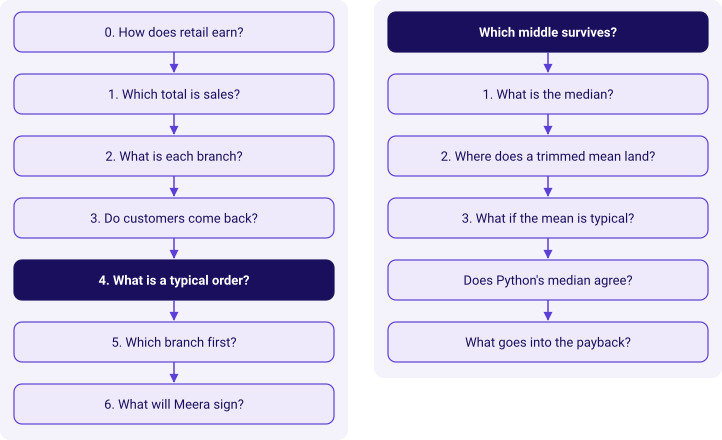

In [2]:
kit.side_by_side(
    kit.vflow(['0. How does retail earn?', '1. Which total is sales?', '2. What is each branch?', '3. Do customers come back?', '4. What is a typical order?', '5. Which branch first?', '6. What will Meera sign?'], lit=4, show=False),
    kit.vflow(['Which middle survives?', '1. What is the median?', '2. Where does a trimmed mean land?', '3. What if the mean is typical?', "Does Python's median agree?", 'What goes into the payback?'], lit=0, show=False),
)

## Which middle survives one large order?

A team could report four middles. The sizing says how far each moves when one **invented**
Rs 90,000 order joins five invented orders of Rs 1,900 to Rs 2,600, which is the test Anand set.

| Option | Work on this file | How far one large order moves it | When it is the right call |
|---|---|---|---|
| A. The mean, total over count | one sum | It moves by every rupee of the large order. | It is right when totals and forecasts must multiply back. |
| B. The median, the middle of the sorted amounts | a sort of 30 | It moves by one place in the sort. | It is right when the question is what a typical order looks like. |
| C. A trimmed mean, dropping the smallest and the largest order | a sort and a sum | It moves little, if the rule trims enough. | It is right when there is a stated rule for how many to drop. |
| D. A mean per customer type | a grouping | It does not move within a type. | It is right when the types are known and each gets its own plan. |

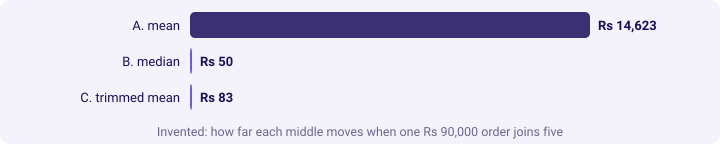

In [3]:
invented = [1900, 2100, 2300, 2400, 2600]                  # invented orders, for the sizing only
plus = sorted(invented + [90000])                          # one invented large order added
def middle(xs):
    xs = sorted(xs); n = len(xs)
    return xs[n // 2] if n % 2 else (xs[n // 2 - 1] + xs[n // 2]) / 2
def trimmed(xs):
    xs = sorted(xs)[1:-1]; return sum(xs) / len(xs)
moves = [("A. mean", sum(plus) / 6 - sum(invented) / 5),
         ("B. median", middle(plus) - middle(invented)),
         ("C. trimmed mean", trimmed(plus) - trimmed(invented))]
kit.bars([(n, round(m)) for n, m in moves], fmt=kit.rupees, lit=(0,),
         title="Invented: how far each middle moves when one Rs 90,000 order joins five")
kit.check("the invented median moves Rs 50", round(moves[1][1]) == 50)
kit.check("the invented mean moves by more than Rs 14,000", moves[0][1] > 14000)

**The best-fit call.** B, the median, survives: it moves Rs 50 when the invented Rs 90,000
order joins, where the mean moves more than Rs 14,000. Report it as the typical order, with A
beside it for totals and the gap between the two stated. **What would change it:**
if marketing prices the payback per customer type, D answers better; that grouping is the
afternoon's second case.

## 1. What is the median Kalpa order?

The median has half the orders below it and half above. With 30 orders there are two middle
values, the 15th and 16th in size order, and the median is halfway between them.

**Predict before you run.** What is the median order?

- a) About Rs 2,200.
- b) Rs 18,160.
- c) Rs 9,080, half the mean.
- d) Rs 2,300, the 16th order in size order.

the two middle orders: Rs 2,110 and Rs 2,300
median: Rs 2,205 | mean: Rs 18,160 | the mean is 8.2 times the median


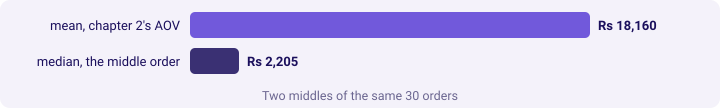

In [4]:
ranked = sorted(amounts)
median = (ranked[14] + ranked[15]) / 2
print("the two middle orders:", kit.rupees(ranked[14]), "and", kit.rupees(ranked[15]))
print("median:", kit.rupees(median), "| mean:", kit.rupees(mean), f"| the mean is {mean / median:.1f} times the median")
kit.bars([("mean, chapter 2's AOV", round(mean)), ("median, the middle order", round(median))],
         fmt=kit.rupees, lit=(1,), title="Two middles of the same 30 orders")
kit.check("the median is Rs 2,205", median == 2205)
kit.check("the mean is about eight times the median", 8 <= mean / median <= 8.5, f"{mean / median:.2f}")

**What happened.** The answer is a: the median Kalpa order is Rs 2,205, halfway between the 15th
and 16th orders, Rs 2,110 and Rs 2,300. The mean of Rs 18,160 sits about eight times above it.

## 2. Where does a trimmed mean of Kalpa's 30 orders land?

Option C in the table, run on the file: drop the smallest and the largest order and average the
other 28. It needs a rule for how many to drop, and it is the middle a spreadsheet user reaches
for first.

**Predict before you run.** Where does the trimmed mean of the 30 land?

- a) Near the mean of Rs 18,160.
- b) Halfway between the mean and the median.
- c) Within about Rs 100 of the median.
- d) Below every order in the file.

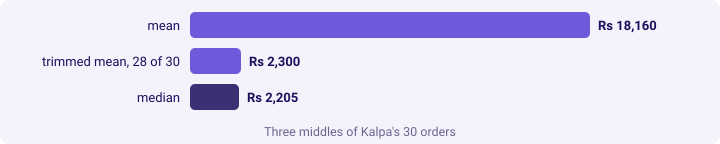

In [5]:
trimmed_kalpa = trimmed(amounts)
definitions = {"booked": {"delivered", "returned", "cancelled"}, "not cancelled": {"delivered", "returned"}}
middles = {}
for name, keep in definitions.items():
    kept = [int(o["amount"]) for o in ORDERS if o["status"] in keep]
    middles[name] = {"orders": len(kept), "mean": sum(kept) / len(kept), "median": middle(kept)}
kit.bars([("mean", round(mean)), ("trimmed mean, 28 of 30", round(trimmed_kalpa)), ("median", round(median))],
         fmt=kit.rupees, lit=(2,), title="Three middles of Kalpa's 30 orders")
kit.check("the trimmed mean lands within Rs 100 of the median", abs(trimmed_kalpa - median) < 100,
          kit.rupees(round(trimmed_kalpa)))
kit.check("the trimmed mean sits more than Rs 15,000 below the mean", mean - trimmed_kalpa > 15000)

**What happened.** The answer is c: the trimmed mean lands at Rs 2,300, beside the median of
Rs 2,205. The rule of one order at each end happened to fit this file, and a file with more very
large orders than the rule trims would leave the trimmed mean far above the median, which is why
the median, which needs no rule, stays the call.

## 3. What goes wrong when the mean is sold as the typical order?

Marketing's slide values each new customer's first order at the average order value.

**Predict before you run.** How many of the 30 orders are larger than the mean of Rs 18,160?

- a) About 15, half of them, since the mean is the middle.
- b) One of them.
- c) Most of them, since the mean sits low.
- d) None of them.

**The plausible wrong answer.** The number as it appears on marketing's slide:

In [6]:
print("A typical Kalpa order:", kit.rupees(mean))
print("What each new customer's first order is worth, per the model:", kit.rupees(mean))

A typical Kalpa order: Rs 18,160
What each new customer's first order is worth, per the model: Rs 18,160


**Why it is wrong.** A typical order is one that most orders look like. If nearly every order
sits below the mean, something at the top is pulling the total, and the mean with it. Priced at
Rs 18,160, a new customer's order looks about eight times the size of the orders Kalpa usually
takes, and Rs 12 crore looks cheap. The check counts the orders above the mean and draws every
amount.

only 1 of the 30 orders sits above the mean of Rs 18,160


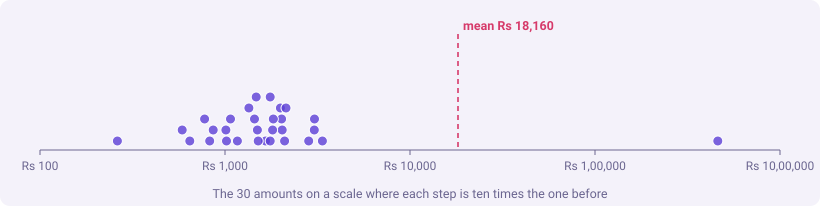

In [7]:
import math
above = sum(1 for a in amounts if a > mean)
print(f"only {above} of the {len(amounts)} orders sits above the mean of {kit.rupees(mean)}")
kit.strip([math.log10(a) for a in amounts], markers=[("mean", math.log10(mean), "bad")],
          lo=2, hi=6, fmt=lambda v: kit.rupees(round(10 ** v)),
          title="The 30 amounts on a scale where each step is ten times the one before")
kit.check("only 1 of the 30 orders sits above the mean", above == 1)
kit.check("the mean sits between the two largest orders", ranked[-2] < mean < ranked[-1])

**What happened.** The answer is b: only 1 of the 30 orders sits above the mean of Rs 18,160,
and the dots pile up below Rs 5,000 while the mean stands far to the right. Sold as typical,
Rs 18,160 values a new customer's order about eight times higher than the median order of
Rs 2,205.

**Your turn.** Which order sits above the mean? Type these lines into the empty cell and run
them, then say in one sentence what kind of order the largest one must be:

```python
print("largest three:", ranked[-3:])
for order in ORDERS:
    if int(order["amount"]) == ranked[-1]:
        print(order)
```

The mechanism on a handful of **invented** numbers, which are not Kalpa orders: five invented
orders between Rs 1,900 and Rs 2,600, then one invented Rs 90,000 order added.

invented records,mean,median
five invented orders,"Rs 2,260","Rs 2,300"
"plus one invented Rs 90,000 order","Rs 16,883","Rs 2,350"


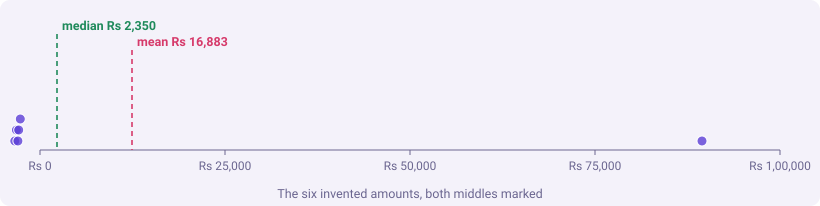

In [8]:
kit.table(["invented records", "mean", "median"],
          [("five invented orders", kit.rupees(sum(invented) / 5), kit.rupees(middle(invented))),
           ("plus one invented Rs 90,000 order", kit.rupees(round(sum(plus) / 6)), kit.rupees(middle(plus)))],
          caption="Invented numbers: what one large order does to each middle")
kit.strip(plus, markers=[("median", middle(plus), "good"), ("mean", round(sum(plus) / 6), "bad")],
          title="The six invented amounts, both middles marked")

The fix is to report the median, Rs 2,205, as the typical order, with the mean beside it for
totals, since mean times count still gives revenue. A payback that credits each new customer's
order with Rs 18,160 overstates a typical order about eightfold, so it is built on the mean
contribution of the customers the spend targets, and chapter 5 sizes the plan on the customer
segments Meera's plan concerns.

## Does Python's own median function give the same middle?

The standard library's `statistics.median` has the rule built in, including the even-count
case. It must agree with the hand-written middle on every definition.

In [9]:
import statistics
rows = []
for name, keep in definitions.items():
    kept = [int(o["amount"]) for o in ORDERS if o["status"] in keep]
    rows.append((name, kit.rupees(middles[name]["median"]), kit.rupees(statistics.median(kept))))
    kit.check(f"{name}: hand-written and library medians agree", statistics.median(kept) == middles[name]["median"])
kit.table(["definition", "sort and take the middle", "statistics.median"], rows,
          caption="Two routes to the median")

definition,sort and take the middle,statistics.median
booked,"Rs 2,205","Rs 2,205"
not cancelled,"Rs 2,100","Rs 2,100"


**What happened.** It does: the hand-written middle and `statistics.median` agree at Rs 2,205 on
booked orders and Rs 2,100 on not-cancelled orders.

**When to switch.** Write the middle by hand once, so you know what the library does with an
even count; after that `statistics.median` is the route, and in Week 2 it becomes
`PERCENTILE_CONT(0.5)` in SQL and `.median()` in pandas. The larger switch is between middles:
the mean comes back whenever a total has to reconcile.

> **Kavya's review.** Anand said "no averages" and you now know why. Put the median in the
> sentence, say the mean is eight times higher, and give the count of orders above it.

### How would you answer an interviewer who asks for a typical order value?

**[S] Mean or median for order value, and why?** "I use the median when a few large orders can
pull the mean, which in retail is almost always, since occasional large buyers sit in the same
file as households. I report both with the count of orders above the mean, because the gap is itself
a finding: on Kalpa's quarter the mean was Rs 18,160, the median Rs 2,205, and only 1 of the 30
orders sat above the mean. The mean keeps its job for totals, since mean times count gives
revenue."

**[S] The mean order is Rs 18,160 and the median Rs 2,205; what do you tell the business about
its orders?** "I tell them that a typical order is about Rs 2,205 and that very large orders
lift the mean to eight times that. I would sort the orders, look at the largest, and ask which customers they
come from, since a plan or a payback is built on the mean of the segments it targets, with the
median quoted as the typical order."

**[D] Which middle would you put in a payback model, and what would make you change it?** "A
payback is a total over a customer's life, so it needs a mean, and the mean has to come from the
customers the spend targets: their mean contribution per customer over the repeat window. The
median is what I quote as the typical order beside it. I would change the segments, and so the
mean, if the spend targeted business buyers."

### How far does one order have to grow before the mean stops describing the file?

One **invented** order grows from Rs 2,600 to Rs 90,000 beside the same five invented orders.
The median never passes Rs 2,500, while the mean follows the growing order all the way.

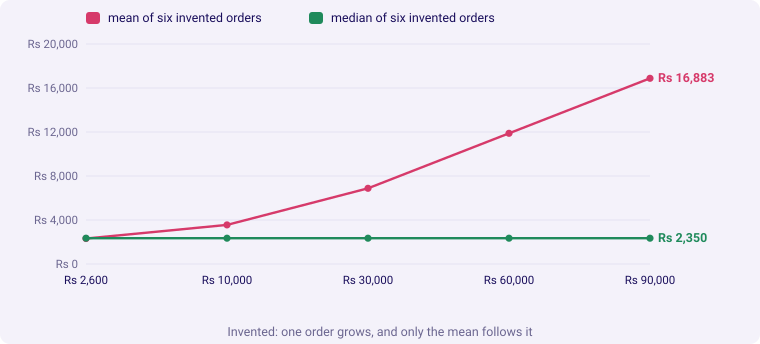

In [10]:
sizes = [2600, 10000, 30000, 60000, 90000]                 # the invented large order, growing
means = [round(sum(invented + [s]) / 6) for s in sizes]
medians = [round(middle(invented + [s])) for s in sizes]
kit.line([kit.rupees(s) for s in sizes], [("mean of six invented orders", means, "bad"),
                                          ("median of six invented orders", medians, "good")],
         fmt=kit.rupees, title="Invented: one order grows, and only the mean follows it")
kit.check("the invented median never passes Rs 2,500", max(medians) <= 2500)

## What goes into the payback case?

The median, Rs 2,205, goes in as the typical order, the payback itself is priced on the mean
contribution of the customers the spend targets, and the booked mean of Rs 18,160 stays beside
the median for totals.

- Which middle survives one large order? The median survives, moving Rs 50 where the mean moves
  more than Rs 14,000 on the invented six.
- What is the median order? It is Rs 2,205, halfway between Rs 2,110 and Rs 2,300.
- Where does a trimmed mean land? It lands at Rs 2,300, near the median, because its rule
  happened to fit this file.
- What goes wrong when the mean is sold as typical? Rs 18,160 is eight times the median, and
  only 1 of the 30 orders sits above it.
- Does Python's median agree? It does, on booked and on not-cancelled orders.

What we now know,The evidence
"The mean is total over count, and it sits far above most orders","Rs 18,160, with only 1 of the 30 orders above it"
The median is the typical order,"Rs 2,205, about one eighth of the mean"
A trimmed mean lands near the median on this file,"Rs 2,300 against Rs 2,205"
"A payback on Rs 18,160 overstates a typical order eightfold",the payback uses the targeted customers' mean


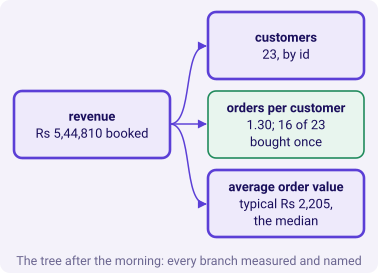

Next: chapter 5 asks which branch Meera opens first.


In [11]:
kit.table(["What we now know", "The evidence"],
          [("The mean is total over count, and it sits far above most orders",
            "Rs 18,160, with only 1 of the 30 orders above it"),
           ("The median is the typical order", "Rs 2,205, about one eighth of the mean"),
           ("A trimmed mean lands near the median on this file", "Rs 2,300 against Rs 2,205"),
           ("A payback on Rs 18,160 overstates a typical order eightfold",
            "the payback uses the targeted customers' mean")],
          caption="Chapter 4: what is a typical order")
kit.driver_tree({"label": "revenue", "note": "Rs 5,44,810 booked", "kind": "known", "children": [
    {"label": "customers", "note": "23, by id", "kind": "known"},
    {"label": "orders per customer", "note": "1.30; 16 of 23 bought once", "kind": "good"},
    {"label": "average order value", "note": "typical Rs 2,205, the median", "kind": "known"}]},
    title="The tree after the morning: every branch measured and named")
kit.check_summary()
print("Next: chapter 5 asks which branch Meera opens first.")